In [2]:
#Load libraries

import glob
import os

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.lines import Line2D

import statsmodels.api as sm
from scipy import stats

import iris
import iris.quickplot as qplt
import iris.analysis
import iris.coord_categorisation as icoca
from iris.util import mask_cube_from_shapefile
from iris.util import promote_aux_coord_to_dim_coord

import cartopy.io.shapereader as shpreader

import pandas as pd
import seaborn as sns

from dataclasses import dataclass

from iris.util import unify_time_units
from iris.util import equalise_attributes

import cmocean

import warnings

import pickle

In [3]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

Finished loading libraries and functions


In [4]:
import dask.optimization

# Patch the missing class
if not hasattr(dask.optimization, 'SubgraphCallable'):
    class SubgraphCallable:
        def __init__(self, *args, **kwargs):
            pass
    dask.optimization.SubgraphCallable = SubgraphCallable


In [5]:
#Models with available data

models = ['ACCESS-ESM1-5', #only sidmassevapsubl for Mid-Holocene (!)
        ###'AWI-ESM-1-1-LR',  # - doesn't have SSP585 ###Needs regrdding, was running in to memory issues
        'CESM2',  #  ### - SSP585 different variant
        'CNRM-CM6-1',  # - SSP585 different variant
        'EC-Earth3-LR',  # - SSP585 is the veg version (EC-Earth3-Veg-LR) ###needs regridding
        'EC-Earth3', ##New one, whoop, whoop!
        #'FGOALS-f3-L',  #     Can't find siconc for piControl, but has it for lig127k
        #'FGOALS-g3',  # Unrealistically highh SIA for the whole of this century
        'HadGEM3-GC3.1-LL',
        'IPSL-CM6A-LR', ###
        'MIROC-ES2L',  # - SSP585 different variant
        'NESM3',  # ###
        'NorESM1-F',  # - doesn't have SSP585
        'NorESM2-LM']  #

In [6]:
#Main parameters

experiment = 'lig127k'
control = 'piControl'

root_path = '/gws/ssde/j25b/pmip4/vol1/public/matt/data/' #'/gws/nopw/j04/pmip4_vol1/public/matt/data/'

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']


t_seconds = 30 * 24 * 60 * 60  #seconds in a month

home_path = '/home/users/matt/'

variable_storage = 'Energy_Budget_vars.pkl'

In [7]:
#Constraints to set the region of interest

con = iris.Constraint(latitude=lambda lat: 59.5 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp


In [8]:
warnings.filterwarnings("ignore")

In [9]:
with open(home_path + variable_storage, 'rb') as f:
    recovered = pickle.load(f)
    experiment_energy_dict = recovered['experiment_energy_dict'] 
    experiment_si_dict = recovered['experiment_si_dict'] 
    experiment_albedo_dict = recovered['experiment_albedo_dict']
    control_energy_dict = recovered['control_energy_dict'] 
    control_si_dict = recovered['control_si_dict'] 
    control_albedo_dict = recovered['control_albedo_dict']
    anomaly_energy_dict = recovered['anomaly_energy_dict'] 
    anomaly_si_dict = recovered['anomaly_si_dict'] 
    anomaly_albedo_dict = recovered['anomaly_albedo_dict']

In [10]:
# ------------------------------------------------------------
# Plot weighted energy vs minSIA anomalies
# ------------------------------------------------------------



def skewed_gaussian_month_weights(mu, sigma, skew, kurt=2, x=None):
    """
    Circular Gaussian month weights with damped skew.

    sigma controls the overall width.
    Large sigma -> nearly uniform weights, regardless of skew.
    """
    if x is None:
        x = np.arange(1, 13)

    if sigma <= 0:
        return None

    # signed circular month difference in [-6, 6)
    d = (x - mu + 6) % 12 - 6
    
    # Gaussian envelope
    g = np.exp(-0.5 * np.abs(d / sigma) ** kurt)

    # Stronger damping: skew vanishes as sigma becomes large
    skew_damping = 1 / (1 + (sigma / 6) ** 2)
    effective_skew = skew #* skew_damping  #remove the skew damping for now. It is not needed for the level of std dev we are get, and just adds complexity

    theta = 2 * np.pi * d / 12.0
    s = np.exp(effective_skew * np.sin(theta))

    w = g * s

    if np.any(~np.isfinite(w)) or np.isclose(w.sum(), 0):
        return None

    return w / w.sum()

mu=6.866
sigma=2.260
skew=0.036

month_weights = skewed_gaussian_month_weights(mu, sigma, skew)

In [11]:
anomaly_energy_dict

{'ACCESS-ESM1-5': {'rsus': array([ 0.12066321,  0.71565486,  1.39553977, -4.48926996, -0.46686397,
          9.34889498, 18.64189143, 21.49142442, 11.85632894,  3.32450714,
          0.59137947,  0.12444753]),
  'rsds': array([ -0.07508444,  -0.42635607,   0.24436091,  12.95816945,
          25.60321244,  17.31809155, -10.94691833, -32.67284831,
         -27.76934229, -11.22292549,  -2.29576672,  -0.37175126]),
  'rlds': array([ 4.29920058,  4.11202095,  2.63813238,  2.39516883, 14.35477638,
         16.55310456, 16.30971646, 11.91781632,  9.67766061,  7.90805583,
          7.48034804,  4.71281568]),
  'rlus': array([ -7.92533682,  -7.33936576,  -5.67265199,  -5.7992564 ,
         -11.66758852,  -9.04950177,  -8.51922108,  -7.76218614,
         -10.35496333, -11.74621541, -11.75650223,  -8.86072043]),
  'hfss': array([-1.27250800e+00, -1.37527339e+00, -1.48048690e+00, -1.64698331e+00,
         -9.86970102e-01,  1.50695546e-03,  1.20844587e+00,  8.14037824e-01,
         -1.29077279e+00,

In [12]:
for model in anomaly_energy_dict.keys():
    weighted_energy = np.zeros(12)

    anomaly_energy_dict[model]['weighted_total'] = np.dot(anomaly_energy_dict[model]['total'], month_weights)

In [13]:
total_list = []

weighted_total_list= []

si_list = []
for model in anomaly_energy_dict.keys():
    total_list.append(np.sum(anomaly_energy_dict[model]['total']))
    weighted_total_list.append(anomaly_energy_dict[model]['weighted_total'])
    si_list.append(min(anomaly_si_dict[model]['siconc']))

Slope: -0.462
95% bootstrap confidence interval: -0.499 to -0.436


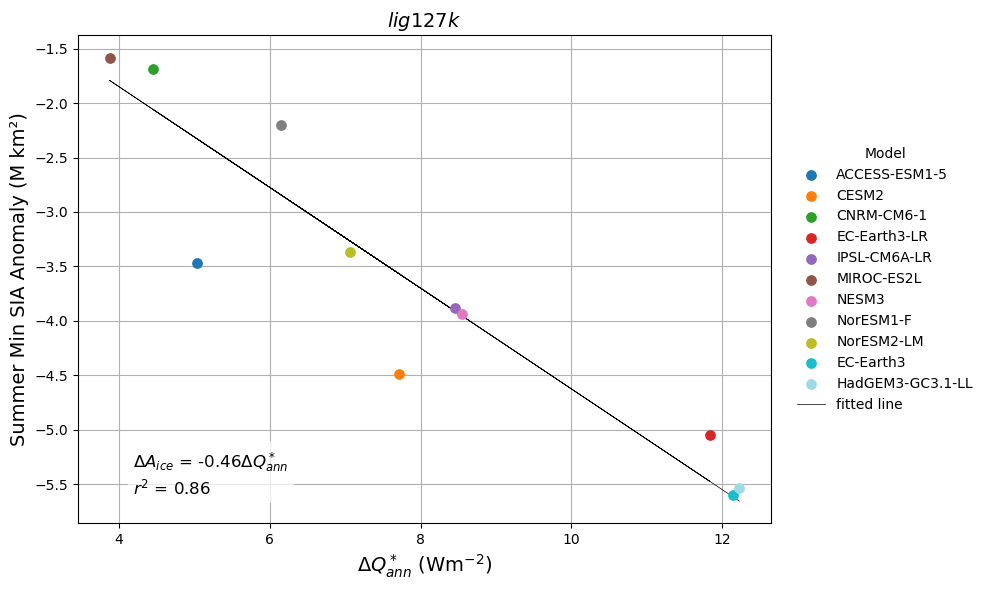

In [41]:

#add line of best fit, with intercept forced to zero

x = np.asarray(weighted_total_list)
y = np.asarray(si_list)

# Use the same model order used to construct weighted_total_list and si_list
model_names = list(anomaly_energy_dict.keys())

if len(model_names) != len(x):
    raise ValueError("Number of model names does not match the number of points")

cmap_name = 'tab10' if len(model_names) <= 10 else 'tab20'
model_colours = plt.get_cmap(cmap_name)(
    np.linspace(0, 1, len(model_names))
)

plt.figure(figsize=(10, 6))
for model, x_value, y_value, colour in zip(
    model_names, x, y, model_colours
):
    plt.scatter(
        x_value,
        y_value,
        color=colour,
        s=45,
        label=model,
        zorder=3
    )

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Best-fit slope through the origin
intercept = 0.0
slope = np.sum(x * y) / np.sum(x**2)

# Bootstrap slopes
rng = np.random.default_rng(42)
n_boot = 10_000

bootstrap_slopes = np.empty(n_boot)

for i in range(n_boot):
    indices = rng.integers(0, len(x), size=len(x))
    x_boot = x[indices]
    y_boot = y[indices]

    bootstrap_slopes[i] = (
        np.sum(x_boot * y_boot) /
        np.sum(x_boot**2)
    )

# 5th and 95th percentile limits
slope_lower, slope_upper = np.percentile(
    bootstrap_slopes, [2.5, 97.5]
)

print(f"Slope: {slope:.3f}")
print(
    f"95% bootstrap confidence interval: "
    f"{slope_lower:.3f} to {slope_upper:.3f}"
)

plt.plot(x, intercept + slope * x, 'k', linestyle='-', linewidth=0.5, label='fitted line')
plt.grid()
plt.xlabel('$\Delta Q_{{ann}}^*$ (Wm$^{-2}$)', fontsize=14)
plt.ylabel('Summer Min SIA Anomaly (M km²)', fontsize=14)
plt.title(r'$\mathit{lig127k}$', fontsize=14)
#display the equation of the line and R-squared value
plt.text(
    0.08,
    0.15,
    f'$\Delta A_{{ice}}$ = {slope:.2f}$\Delta Q_{{ann}}^*$\n'
    f'$r^2$ = {r_value**2:.2f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        boxstyle='square,pad=0.3',
        alpha=0.75
    )
)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    title='Model',
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()


Text(0.05, 0.95, 'y = 0.023x + -3.580\n$R^2$ = 0.213')

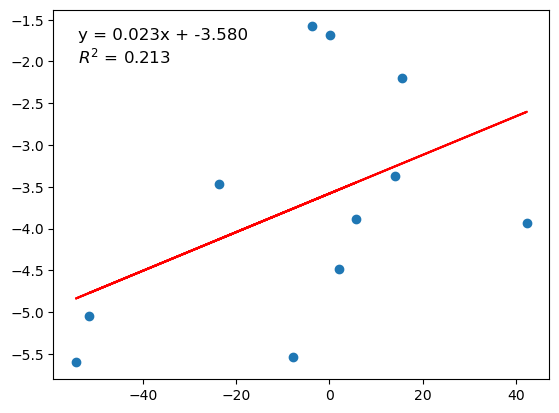

In [15]:
#add line of best fit, with intercept forced to zero

x = np.asarray(total_list)
y = np.asarray(si_list)

plt.plot(x, y, 'o')

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
#slope = np.sum(x * y) / np.sum(x**2)
#intercept = 0.0

plt.plot(x, intercept + slope * x, 'r', label='fitted line')
#display the equation of the line and R-squared value
plt.text(0.05, 0.95, f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_value**2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')